In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt
from animations.utils import *
import json 
from pathlib import Path
import pandas as pd
from pprint import pprint

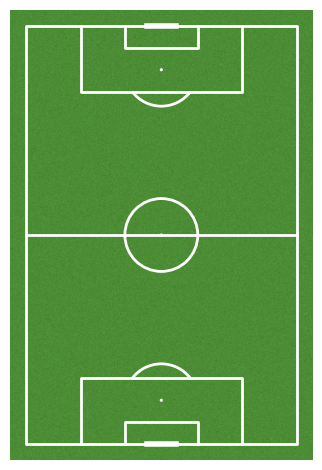

In [2]:
VerticalPitch = VerticalPitch(pitch_type='custom', pitch_width=68, pitch_length=105, pitch_color='grass', line_color='white')

fig, ax = VerticalPitch.draw()
plt.show()

# Understanding Ball Tracking Data

In [3]:
import json 
from pathlib import Path
import pandas as pd
from pprint import pprint

tracking_dir = Path("../data/euro2024/2036198/20240629_SUI-2-0-ITA_2036198/2036198_Switzerland_Italy")
json_path = tracking_dir / "scrubbed.samples.ball/2024_3_2036198_1_1.football.samples.ball"

with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

print(json.dumps(data, indent=2, ensure_ascii=False))

{
  "details": {
    "competition": {
      "name": "European Championship",
      "id": {
        "heId": "ef84e376-52b9-48c5-ab03-08d958b63c6b",
        "uefaId": "3"
      },
      "year": 2024
    },
    "match": {
      "id": {
        "heId": "3c3145ca-cf3f-41ff-5731-08dc39425c39",
        "uefaId": "2036198"
      }
    },
    "venue": {
      "name": "Olympiastadion",
      "id": {
        "heId": "3c1a29bb-62de-40c5-be9e-08da31a972a5",
        "uefaId": "62875"
      }
    },
    "teams": [
      {
        "id": {
          "heId": "d31d15d4-762e-4322-656a-08d958b64317",
          "uefaId": "66"
        },
        "name": "Italy",
        "home": false
      },
      {
        "id": {
          "heId": "ac162b14-78d7-4837-6571-08d958b64317",
          "uefaId": "128"
        },
        "name": "Switzerland",
        "home": true
      }
    ]
  },
  "samples": {
    "ball": [
      {
        "speed": {
          "mph": 39.180004335812455,
          "mps": 17.515000105417425
  

In [4]:
pprint(data['details'])

{'competition': {'id': {'heId': 'ef84e376-52b9-48c5-ab03-08d958b63c6b',
                        'uefaId': '3'},
                 'name': 'European Championship',
                 'year': 2024},
 'match': {'id': {'heId': '3c3145ca-cf3f-41ff-5731-08dc39425c39',
                  'uefaId': '2036198'}},
 'teams': [{'home': False,
            'id': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317',
                   'uefaId': '66'},
            'name': 'Italy'},
           {'home': True,
            'id': {'heId': 'ac162b14-78d7-4837-6571-08d958b64317',
                   'uefaId': '128'},
            'name': 'Switzerland'}],
 'venue': {'id': {'heId': '3c1a29bb-62de-40c5-be9e-08da31a972a5',
                  'uefaId': '62875'},
           'name': 'Olympiastadion'}}


In [5]:
ball_tracking_data = data['samples']['ball']
times = [it['time'] for it in ball_tracking_data if 'time' in it]
print(f"Number of frames in a second -> {len(times)/60}")
print(len(ball_tracking_data))
print(times)

Number of frames in a second -> 22.85
1371
[0.01838, 0.05838, 0.09838, 0.13838, 0.17838, 0.21838, 0.25838, 0.29838, 0.33838, 0.37838, 0.41838, 0.45838, 0.49838, 0.53838, 0.57838, 0.61838, 0.65838, 0.69838, 0.73838, 0.77838, 0.81838, 0.85838, 0.89838, 0.93838, 0.97838, 1.01838, 1.05838, 1.09838, 1.13838, 1.17838, 1.21838, 1.25838, 1.29838, 1.33838, 1.37838, 1.41838, 1.45838, 1.49838, 1.53838, 1.57838, 1.61838, 1.65838, 1.69838, 1.73838, 1.77838, 1.81838, 1.85838, 1.89838, 1.93838, 1.97838, 2.01838, 2.05838, 2.09838, 2.13838, 2.17838, 2.21838, 2.25838, 2.29838, 2.33838, 2.37838, 2.41838, 2.45838, 2.49838, 2.53838, 2.57838, 2.61838, 2.65838, 2.69838, 2.73838, 2.77838, 2.81838, 2.85838, 2.89838, 2.93838, 2.97838, 3.01838, 3.05838, 3.09838, 3.13838, 3.17838, 3.21838, 3.25838, 3.29838, 3.33838, 3.37838, 3.41838, 3.45838, 3.49838, 3.53838, 3.57838, 3.61838, 3.65838, 3.69838, 3.73838, 3.77838, 3.81838, 3.85838, 3.89838, 3.93838, 3.97838, 4.01838, 4.05838, 4.09838, 4.13838, 4.17838, 4.21838, 4.

In [6]:
pprint(ball_tracking_data[260], compact=False, width=120)

{'bounds': 'In',
 'distance': {'feet': 1.0129652194026275, 'metres': 0.30875178899386363},
 'play': 'In',
 'pos': [-28.197077003776567, 15.69188950037294, 1.6439351293085558],
 'possession': {'teamId': {'heId': 'ac162b14-78d7-4837-6571-08d958b64317', 'uefaId': '128'}},
 'speed': {'mph': 17.266480671798334, 'mps': 7.718794724846591},
 'time': 10.41838}


{'bounds': 'In',
 'distance': {'feet': 0.4196723175454079, 'metres': 0.12791611829452454},
 'play': 'Out',
 'pos': [-36.59708352598735, 34.06710821468259, 0.9881974101833553],
 'possession': {'teamId': {'heId': 'ac162b14-78d7-4837-6571-08d958b64317',
                           'uefaId': '128'}},
 'speed': {'mph': 7.153517041443843, 'mps': 3.1979029573631133},
 'time': 19.85838}
{'bounds': 'In',
 'distance': {'feet': 0.5065270361446177, 'metres': 0.15438943567641752},
 'play': 'Out',
 'pos': [-36.509244292022885, 33.964612642742956, 1.0631308777248059],
 'possession': {'teamId': {'heId': 'ac162b14-78d7-4837-6571-08d958b64317',
                           'uefaId': '128'}},
 'speed': {'mph': 8.633997606050135, 'mps': 3.859735891910438},
 'time': 19.89838}
{'bounds': 'In',
 'distance': {'feet': 0.5413485838686111, 'metres': 0.16500304308305527},
 'play': 'Out',
 'pos': [-36.4618917171579, 33.97397300472767, 1.2209159261414397],
 'possession': {'teamId': {'heId': 'ac162b14-78d7-4837-6571-08

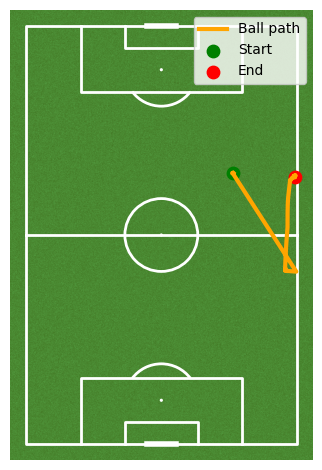

In [7]:
out_of_play_pos = []

for sample in ball_tracking_data:
    if sample['bounds'] != sample['play']:
        out_of_play_pos.append(sample['pos'])
        pprint(sample)

out_of_play_pos = np.array(out_of_play_pos)
out_of_play_x, out_of_play_y = align_points_and_return_xy(out_of_play_pos)

plot_xy_track_2d(out_of_play_x, out_of_play_y)

-5.032579314620854 69.58618696012996
33.15786398644954 68.98881333115469


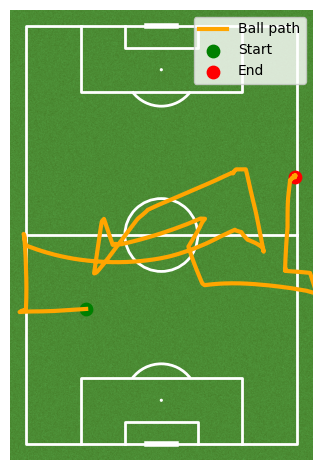

In [8]:

import numpy as np
# Get ball positions
ball_pos = np.array([it['pos'] for it in ball_tracking_data])
x,y = align_points_and_return_xy(ball_pos)
print(min(x), max(x))
print(min(y), max(y))

plot_xy_track_2d(x, y)

# Understanding Centroid Data

In [9]:
centroid_data_path = tracking_dir / "scrubbed.samples.centroids/2024_3_2036198_1_1.football.samples.centroids"

with centroid_data_path.open("r", encoding="utf-8") as f:
    centroid_data = json.load(f)

pprint(centroid_data['details'])

{'competition': {'id': {'heId': 'ef84e376-52b9-48c5-ab03-08d958b63c6b',
                        'uefaId': '3'},
                 'name': 'European Championship',
                 'year': 2024},
 'match': {'id': {'heId': '3c3145ca-cf3f-41ff-5731-08dc39425c39',
                  'uefaId': '2036198'}},
 'players': [{'gender': 'Mens',
              'id': {'heId': '9c263634-b6fb-46a0-7386-08d958b7d325',
                     'uefaId': '250078922'},
              'jerseyNumber': '1',
              'role': {'id': 1, 'name': 'Goalkeeper'},
              'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317',
                         'uefaId': '66'}},
             {'gender': 'Mens',
              'id': {'heId': '92d11e98-1626-405b-7387-08d958b7d325',
                     'uefaId': '250064229'},
              'jerseyNumber': '2',
              'role': {'id': 2, 'name': 'Defender'},
              'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317',
                         'uefaId': '66'}

In [10]:
players = centroid_data['details']['players']
goalkeepers = retrieve_goalkeepers_id(players)
pprint(goalkeepers)

[{'gender': 'Mens',
  'id': {'heId': '9c263634-b6fb-46a0-7386-08d958b7d325', 'uefaId': '250078922'},
  'jerseyNumber': '1',
  'role': {'id': 1, 'name': 'Goalkeeper'},
  'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317', 'uefaId': '66'}},
 {'gender': 'Mens',
  'id': {'heId': '8b2f77cf-569b-48f1-6fb8-08db52466610', 'uefaId': '250178594'},
  'jerseyNumber': '12',
  'role': {'id': 1, 'name': 'Goalkeeper'},
  'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317', 'uefaId': '66'}},
 {'gender': 'Mens',
  'id': {'heId': '9fd27795-6214-4617-7392-08d958b7d325', 'uefaId': '250066753'},
  'jerseyNumber': '26',
  'role': {'id': 1, 'name': 'Goalkeeper'},
  'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317', 'uefaId': '66'}},
 {'gender': 'Mens',
  'id': {'heId': '1cc2530b-3412-4ec8-742a-08d958b7d325', 'uefaId': '97746'},
  'jerseyNumber': '1',
  'role': {'id': 1, 'name': 'Goalkeeper'},
  'teamId': {'heId': 'ac162b14-78d7-4837-6571-08d958b64317', 'uefaId': '128'}},
 {'gender': 'Mens

In [11]:
print(f"Number of samples: {len(centroid_data['samples']['people'])}")
print(f"Number of players: {len(centroid_data['details']['players'])}")

Number of samples: 37500
Number of players: 50


In [12]:
samples = centroid_data['samples']['people']
retrieve_tracking_data_for_player(samples, '9c263634-b6fb-46a0-7386-08d958b7d325')

[{'centroid': [{'speed': {'mph': 0, 'mps': 0},
    'distance': {'metres': 0, 'feet': 0},
    'pos': [-45.7553825378418, 0.03259729966521263],
    'time': 0.01838}],
  'personId': {'heId': '9c263634-b6fb-46a0-7386-08d958b7d325',
   'uefaId': '250078922'},
  'role': {'id': 2, 'name': 'Goalkeeper'},
  'trackId': 17741},
 {'centroid': [{'speed': {'mph': 1.6533785464240471,
     'mps': 0.7391251202196067},
    'distance': {'metres': 0.02956500480878427, 'feet': 0.09699805037685179},
    'pos': [-45.7258186340332, 0.032852448523044586],
    'time': 0.05838}],
  'personId': {'heId': '9c263634-b6fb-46a0-7386-08d958b7d325',
   'uefaId': '250078922'},
  'role': {'id': 2, 'name': 'Goalkeeper'},
  'trackId': 17741},
 {'centroid': [{'speed': {'mph': 1.5102712450342581,
     'mps': 0.6751505382505825},
    'distance': {'metres': 0.027006021530023298, 'feet': 0.08860243567656163},
    'pos': [-45.69882583618164, 0.032007426023483276],
    'time': 0.09838}],
  'personId': {'heId': '9c263634-b6fb-46a0-

In [13]:
for gk in goalkeepers:
    if len(retrieve_tracking_data_for_player(samples, gk['id']['heId'])) > 0:
        print(gk)

{'role': {'id': 1, 'name': 'Goalkeeper'}, 'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317', 'uefaId': '66'}, 'jerseyNumber': '1', 'id': {'heId': '9c263634-b6fb-46a0-7386-08d958b7d325', 'uefaId': '250078922'}, 'gender': 'Mens'}
{'role': {'id': 1, 'name': 'Goalkeeper'}, 'teamId': {'heId': 'ac162b14-78d7-4837-6571-08d958b64317', 'uefaId': '128'}, 'jerseyNumber': '1', 'id': {'heId': '1cc2530b-3412-4ec8-742a-08d958b7d325', 'uefaId': '97746'}, 'gender': 'Mens'}


[[-4.57553825e+01  3.25972997e-02]
 [-4.57258186e+01  3.28524485e-02]
 [-4.56988258e+01  3.20074260e-02]
 ...
 [-5.09657135e+01  7.01862797e-02]
 [-5.09525833e+01  6.54562563e-02]
 [-5.09388771e+01  5.65299839e-02]]


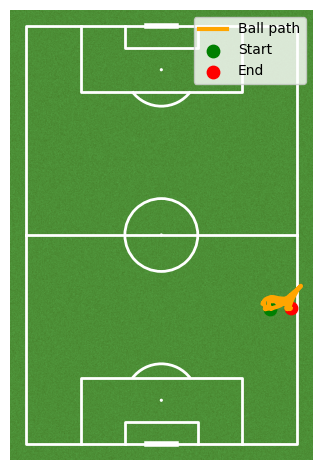

In [14]:
donnaruma_tracking = retrieve_tracking_data_for_player(samples, "9c263634-b6fb-46a0-7386-08d958b7d325")
donnaruma_centroids = np.array([it['centroid'][0]['pos'] for it in donnaruma_tracking])
print(donnaruma_centroids)
dx, dy = align_points_and_return_xy(donnaruma_centroids)
plot_xy_track_2d(dx,dy)

[[ 4.74739990e+01  4.48509678e-02]
 [ 4.74684601e+01  4.06508744e-02]
 [ 4.74608307e+01  3.40576023e-02]
 ...
 [ 1.80991135e+01 -1.44296974e-01]
 [ 1.81120739e+01 -1.44458935e-01]
 [ 1.81278038e+01 -1.45233631e-01]]


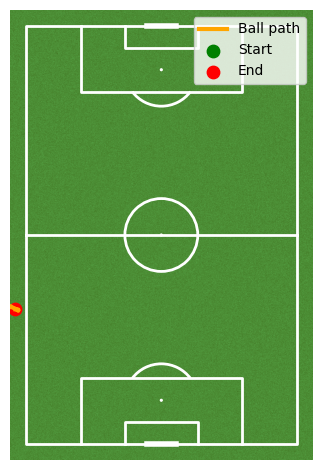

In [15]:
sommer_tracking = retrieve_tracking_data_for_player(samples, "1cc2530b-3412-4ec8-742a-08d958b7d325")
sommer_centroids = np.array([it['centroid'][0]['pos'] for it in sommer_tracking])
print(sommer_centroids)
dx, dy = align_points_and_return_xy(sommer_centroids)
plot_xy_track_2d(dx,dy)

Looping through the all the minutes to extract position across 90 minutes. 

In [16]:
SOMMER_ID = "1cc2530b-3412-4ec8-742a-08d958b7d325"
DONNARUMA_ID = "9c263634-b6fb-46a0-7386-08d958b7d325"
all_donnaruma_data = []
all_sommer_data = []

base = tracking_dir / "scrubbed.samples.centroids"
prefix = "2024_3_2036198"

def load_file(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

loaded = {}  # minute -> data

for minute in range(1, 91):
    half = 1 if minute <= 45 else 2

    # candidate 1: half + absolute minute (e.g. _2_46)
    path = base / f"{prefix}_{half}_{minute}.football.samples.centroids"

    if path is None:
        print(f"missing file for minute {minute}")
        continue

    data = load_file(path)
    samples = data['samples']['people']
    loaded[minute] = data
    
    all_donnaruma_data.extend(retrieve_tracking_data_for_player(samples, DONNARUMA_ID))
    all_sommer_data.extend(retrieve_tracking_data_for_player(samples, SOMMER_ID))

In [17]:
len(all_sommer_data)

135000

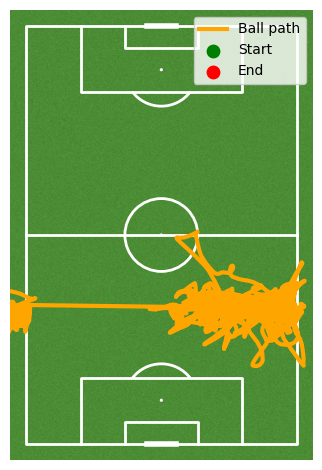

In [18]:
all_sommer_centroids = np.array([it['centroid'][0]['pos'] for it in all_sommer_data])
all_sommer_x, all_sommer_y = align_points_and_return_xy(all_sommer_centroids)
plot_xy_track_2d(all_sommer_x,all_sommer_y)

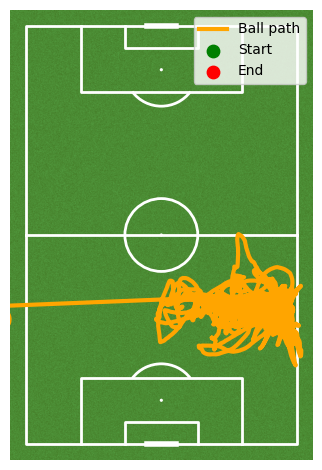

In [19]:
all_donnaruma_centroids = np.array([it['centroid'][0]['pos'] for it in all_donnaruma_data])

all_donnaruma_x, all_donnaruma_y = align_points_and_return_xy(all_donnaruma_centroids)
plot_xy_track_2d(all_donnaruma_x,all_donnaruma_y)

# Understanding Joints Data


In [20]:
joints_data_path = tracking_dir / "scrubbed.samples.joints/2024_3_2036198_1_1.football.samples.joints"

with joints_data_path.open("r", encoding="utf-8") as f:
    joints_data = json.load(f)

pprint(joints_data['details'])

{'competition': {'id': {'heId': 'ef84e376-52b9-48c5-ab03-08d958b63c6b',
                        'uefaId': '3'},
                 'name': 'European Championship',
                 'year': 2024},
 'match': {'id': {'heId': '3c3145ca-cf3f-41ff-5731-08dc39425c39',
                  'uefaId': '2036198'}},
 'players': [{'id': {'heId': '9c263634-b6fb-46a0-7386-08d958b7d325',
                     'uefaId': '250078922'},
              'jerseyNumber': '1',
              'role': {'id': 1, 'name': 'Goalkeeper'},
              'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317',
                         'uefaId': '66'}},
             {'id': {'heId': '92d11e98-1626-405b-7387-08d958b7d325',
                     'uefaId': '250064229'},
              'jerseyNumber': '2',
              'role': {'id': 2, 'name': 'Defender'},
              'teamId': {'heId': 'd31d15d4-762e-4322-656a-08d958b64317',
                         'uefaId': '66'}},
             {'id': {'heId': '43fe2de1-d078-4cd9-850e-08d9737

In [21]:
unique_people_id = []
unique_type = []
unique_joint_type = joints_data['samples']['people'][0]["joints"][0].keys()
for joint in joints_data['samples']['people']:
    if joint["trackId"] not in unique_people_id:
        unique_people_id.append(joint["trackId"])
    if joint["role"]["name"] not in unique_type:
        unique_type.append(joint["role"]["name"])
    if len(joint["joints"]) != 1:
        print("Something wrong!")
    if joint["joints"][0].keys() != unique_joint_type:
        print("Something wrong!")

print(len(unique_people_id))
print(unique_type)
print(unique_joint_type)

25
['Outfielder', 'Goalkeeper', 'AssistantReferee2', 'Referee', 'AssistantReferee1']
dict_keys(['lAnkle', 'lEar', 'lElbow', 'lEye', 'lHip', 'lKnee', 'lShoulder', 'lWrist', 'neck', 'nose', 'rAnkle', 'rEar', 'rElbow', 'rEye', 'rHip', 'rKnee', 'rShoulder', 'rWrist', 'midHip', 'lBigToe', 'rBigToe', 'lSmallToe', 'rSmallToe', 'lHeel', 'rHeel', 'lThumb', 'lPinky', 'rThumb', 'rPinky', 'time'])


# Merging Centroid and Joints Data

In [22]:
# before we merge, we first need to make sure if the times are aligned

centroids_1_path = tracking_dir / "scrubbed.samples.centroids/2024_3_2036198_1_1.football.samples.centroids"

with centroids_1_path.open("r", encoding="utf-8") as f:
    centroids_1_data = json.load(f)

joints_1_path = tracking_dir / "scrubbed.samples.joints/2024_3_2036198_1_1.football.samples.joints"

with joints_1_path.open("r", encoding="utf-8") as f:
    joints_1_data = json.load(f)

In [23]:
num_samples = len(joints_1_data["samples"]["people"])
if num_samples != len(centroids_1_data["samples"]["people"]): print("something wrong!")

for i in range(num_samples):
    joints_sample_time = joints_1_data["samples"]["people"][i]["joints"][0]["time"]
    centroids_sample_time = centroids_1_data["samples"]["people"][i]["centroid"][0]["time"]
    if joints_sample_time != centroids_sample_time:
        print("Error: time did not match!")
        break

print("All sample times matched!")

All sample times matched!


# Get Goalkeeper Event Times and Types

In [24]:
events_path = Path("../data/euro2024/2036198/2036198_Raw_Event_Files.json")

with events_path.open("r", encoding="utf-8") as f:
    events = json.load(f)

In [25]:
gk_events = []
goals = []
for event in events:
    attributes = event["Attributes"]
    if any("goalkeeper" in s.lower() for s in attributes):
        gk_events.append(event)
    if "Goal" in event["Tags"]:
        goals.append(event)

In [26]:
len(gk_events)

17

In [27]:
for goal in goals:
    print(f"At match time {goal['MatchTime']}, the following happened: {goal['Tags']}")

At match time 00:36:22.3270000, the following happened: ['BallTouch', 'Goal']
At match time 00:45:29.0320000, the following happened: ['BallTouch', 'Goal']


In [28]:
for gk_event in gk_events:
    print(f"At match time {gk_event['MatchTime']}, the following happened: {gk_event['Tags']}")

At match time 00:02:51.3270000, the following happened: ['BallTouch', 'ThrowIn']
At match time 00:11:26.8470000, the following happened: ['BallTouch', 'ThrowIn']
At match time 00:16:53.9670000, the following happened: ['BallTouch', 'ThrowIn']
At match time 00:22:13.4660000, the following happened: ['BallTouch', 'ThrowIn']
At match time 00:23:29.4870000, the following happened: ['BallTouch', 'Save']
At match time 00:28:07.9670000, the following happened: ['BallTouch', 'ThrowIn']
At match time 00:31:33.4470000, the following happened: ['BallTouch', 'ThrowIn']
At match time 00:45:14.6900000, the following happened: ['BallTouch', 'Save']
At match time 00:58:53.5060000, the following happened: ['BallTouch', 'ThrowIn']
At match time 01:05:54.9920000, the following happened: ['BallTouch', 'ThrowIn']
At match time 01:12:21.9520000, the following happened: ['BallTouch', 'Save']
At match time 01:14:24.5520000, the following happened: ['BallTouch', 'ThrowIn']
At match time 01:16:54.9120000, the f

# Visualising Skeleton

In [ ]:
gk_samples_path = Path("../data/euro2024/2036198/goalkeeper_samples.json")

with gk_samples_path.open("r", encoding="utf-8") as f:
    gk_samples = json.load(f)

In [ ]:
gk_samples.keys()

In [ ]:
from animations.utils import plot_skeleton_3d, animate_skeleton

bones = [(11, 13), (13, 9), (9, 3), (3,1), (9, 8), (8, 6), (8, 16), (16, 12), (12, 17), (17, 28), (12, 27), (6, 2), (2, 7), (7, 25), (7, 26), (8, 18), (18, 14), (14, 15), (15, 10), (10, 24), (10, 20), (20, 22), (18, 4), (4, 5), (5,0), (0,23), (0, 19), (19, 21)]

body_part_mapping = {
    0: "lAnkle",
    1: "lEar",
    2: "lElbow",
    3: "lEye",
    4: "lHip",
    5: "lKnee",
    6: "lShoulder",
    7: "lWrist",
    8: "neck",
    9: "nose",
    10: "rAnkle",
    11: "rEar",
    12: "rElbow",
    13: "rEye",
    14: "rHip",
    15: "rKnee",
    16: "rShoulder",
    17: "rWrist",
    18: "midHip",
    19: "lBigToe",
    20: "rBigToe",
    21: "lSmallToe",
    22: "rSmallToe",
    23: "lHeel",
    24: "rHeel",
    25: "lThumb",
    26: "lPinky",
    27: "rThumb",
    28: "rPinky"
}
body_part_ids = {v: k for k, v in body_part_mapping.items()}

In [ ]:
gk_samples["250078922"][0]

In [ ]:
import random
random_idx = random.randint(0, len(gk_samples["250078922"]) - 1)
print(random_idx)
frames = gk_samples["250078922"][(23*60 + 25) * 25: (23*60 + 25 + 10) * 25]

In [ ]:
frames

In [ ]:
joints_all_frames = []
for frame in frames:

    joints = [None] * len(body_part_ids)

    for body_part in body_part_ids:
        id = body_part_ids[body_part]
        joints[id] = tuple(frame[body_part])
    joints_all_frames.append(joints)

In [ ]:
joints_all_frames

In [ ]:
ani = animate_skeleton(joints_all_frames, bones)
ani.save('data/videos/donnaruma_save_skeleton.mp4', writer='ffmpeg', fps=20, dpi=150)

# Data Cleaning

In [29]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import concurrent.futures
from tqdm.auto import tqdm
import functools

c:\Users\afons\OneDrive\Desktop\SemesterProject\goalkeeping-skeletal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from preprocessing.cleaning_utils import get_player_sequence

PLAYER_ID = "1cc2530b-3412-4ec8-742a-08d958b7d325"

centroids_dir = tracking_dir / "scrubbed.samples.centroids"
joints_dir = tracking_dir / "scrubbed.samples.joints"

print(f"Extracting data for player: {PLAYER_ID}")

# Process directories sequentially, but files within them in parallel.
# This prevents the disk from trashing by trying to read two folders at once.
player_com = get_player_sequence(centroids_dir, PLAYER_ID, 'centroid')
player_hips_2d = get_player_sequence(joints_dir, PLAYER_ID, 'joints')

Extracting data for player: 1cc2530b-3412-4ec8-742a-08d958b7d325


In [33]:
print(len(player_com[0]))

2


In [38]:
print(player_hips_2d[0])

{'lAnkle': [47.44331741333008, -0.2699110507965088, 0.17377600073814392], 'lEar': [47.097103118896484, -0.02791845053434372, 1.5882848501205444], 'lElbow': [47.40178680419922, -0.19736115634441376, 1.1403542757034302], 'lEye': [47.000762939453125, 0.029338127002120018, 1.5386141538619995], 'lHip': [47.46171951293945, -0.06639917194843292, 0.890554666519165], 'lKnee': [47.35397720336914, -0.1874864101409912, 0.5689539909362793], 'lShoulder': [47.21010208129883, -0.11673685908317566, 1.3847843408584595], 'lWrist': [47.34293746948242, -0.16183312237262726, 0.9316450953483582], 'neck': [47.19679260253906, 0.06767331808805466, 1.4228432178497314], 'nose': [46.98646545410156, 0.059749722480773926, 1.4885203838348389], 'rAnkle': [47.46798324584961, 0.3095170855522156, 0.17714327573776245], 'rEar': [47.093807220458984, 0.15192048251628876, 1.5900030136108398], 'rElbow': [47.407196044921875, 0.34080955386161804, 1.1433205604553223], 'rEye': [47.00012969970703, 0.0962865799665451, 1.538438558578

In [36]:
all_com = []
for minute in player_com:
    all_com.extend(minute)
print(len(all_com))

all_hips = []
for minute in player_hips_2d:
    all_hips.extend(minute)
print(len(all_hips))

285218
4278270


In [ ]:
print("Data extraction complete. Aligning data...")

# Convert to numpy arrays
valid_com = np.array(all_com)
valid_hips = np.array(all_hips)

# Calculate Euclidean distance
deviations = np.linalg.norm(valid_com - valid_hips, axis=1)

# Statistics
mean_dev = np.mean(deviations)
max_dev = np.max(deviations)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(deviations, label='Deviation', linewidth=0.8, alpha=0.8)
plt.axhline(mean_dev, color='r', linestyle='--', label=f'Mean: {mean_dev:.2f}')

plt.title(f'CoM vs Mid-Hip Deviation (Player {PLAYER_ID[:8]}...)')
plt.xlabel('Frame Index (synced)')
plt.ylabel('Distance (units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLAYER_ID}_deviation")


Data extraction complete. Aligning data...


TypeError: string indices must be integers, not 'str'